# Student name: Nofri Alhadi

# Student ID: 23188901

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import preprocessing
import math
import random
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve
from sklearn.model_selection import ShuffleSplit
import pandas as pd
from sklearn.neural_network import MLPClassifier
from tabulate import tabulate


In [3]:
# Suppressing Warnings:
import warnings
warnings.filterwarnings("ignore")

# Task 1
### Purpose 
*To check your understanding of key terms used throughout this module.*



## Question
How a perceptron can be used to classify two objects given their circumference and weight. You may assume that these two features result in the linear separability of the two classes in the given dataset. Use the following terms in your description:

- Input space
- Output space
- Unknown target function
- Data set
- Hypothesis set
- Final Hypothesis
- Error measure
- In-sample error
- Out-of-sample error

## Answer

The perceptron's weights are modified during training to improve its generalisation ability. The goal is to find a hypothesis that closely approximates the target function. After training, the perceptron can classify new objects based on their weight and circumference.

### Input Space
The input space is defined by the circumference and weight of the objects and consists of all possible combinations of these features.

### Output space
The set of possible outputs that the perceptron can produce. for this case, we are dealing with binary classification or two objects, which is {+1, -1}.

### Unknown target function
The true classification of objects based on their circumference and weight is the ideal mapping from the input space to the output space, which we’re trying to learn from the data.

### Data set
The data set contains instances with known input features (circumference and weight) and their corresponding class labels, which are either +1 or -1.
| Circumference | Weight | Class |
|---------------|--------|-------|
|      ...      |  ...   |   +1  |
|      ...      |  ...   |   -1  |

### Hypothesis set
The set of possible linear separators that can classify objects based on their circumference and weight.

### Final Hypothesis
The specific linear separator that the perceptron learns from the training data.

### Error measure
The error measure is a metric that helps to measure how well the perceptron's output matches the true class labels. In the case of perceptron learning, the misclassification error is a commonly used error measure. It calculates the number of instances that are incorrectly classified.

### In-sample error
The in-sample error is the error measure calculated on the training data. It represents how well the perceptron performs on the data it has seen during training.

### Out-of-sample error
The out-of-sample error measures how well the perceptron is expected to perform on unseen data.

# Task 2
Learning curves allow us to look at the impact that the size of the training data set N has on the ability to keep the difference between $E_{in}$ and $E_{out}$ small.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.datasets import load_digits
from sklearn.model_selection import learning_curve
from sklearn.model_selection import ShuffleSplit


def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure()
    plt.title(title, fontsize=14)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Error")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    
    train_errors = 1- train_scores
    test_errors = 1-test_scores
    
    train_errors_mean = np.mean(train_errors, axis=1)
    train_errors_std = np.std(train_errors, axis=1)
    test_errors_mean = np.mean(test_errors, axis=1)
    test_errors_std = np.std(test_errors, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_errors_mean - train_errors_std,
                     train_errors_mean + train_errors_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_errors_mean - test_errors_std,
                     test_errors_mean + test_errors_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_errors_mean, 'o-', color="r",
             label="Training error")
    plt.plot(train_sizes, test_errors_mean, 'o-', color="g",
             label="Test error")

    
    plt.legend(loc="best")
    
    print(f'train sizes: {train_sizes}')
    print(f'train_errors_mean: {train_errors_mean}')
    print(f'test_errors_mean: {test_errors_mean}')
    
    return plt

In [5]:
data = np.loadtxt("Et1_Task2.csv", delimiter=",")
X = data[:,0:2]
y = data[:,2]

## Logistic Regression Learning Curve

In [6]:
cv = ShuffleSplit(n_splits=25, test_size=0.2)

train sizes: [  8 106 204 302 400]
train_errors_mean: [0.105      0.14943396 0.15666667 0.15827815 0.1571    ]
test_errors_mean: [0.2052 0.1628 0.1604 0.159  0.159 ]


<module 'matplotlib.pyplot' from '/Users/nofrialhadi/anaconda3/lib/python3.11/site-packages/matplotlib/pyplot.py'>

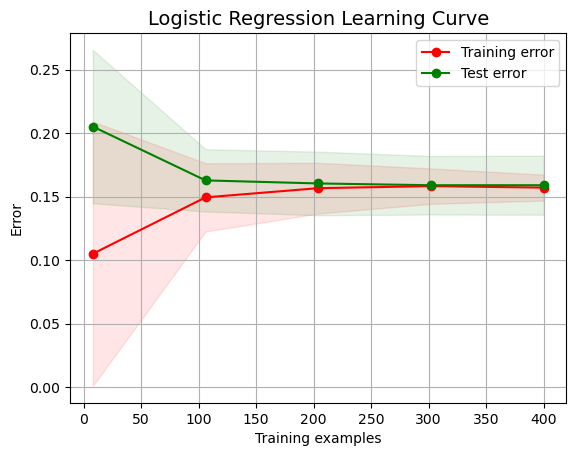

In [7]:
estimator = LogisticRegression(random_state=0, solver='lbfgs',multi_class='multinomial')
plot_learning_curve(estimator, "Logistic Regression Learning Curve", X, y, cv=cv, n_jobs=4, train_sizes = np.linspace(0.01, .5, 5))

## Neural Network Learning Curves

/Users/nofrialhadi/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/nofrialhadi/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/nofrialhadi/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed t

train sizes: [  8 106 204 302 400]
train_errors_mean: [0.01       0.00566038 0.01333333 0.02966887 0.0405    ]
test_errors_mean: [0.241  0.138  0.129  0.1248 0.1134]


/Users/nofrialhadi/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/nofrialhadi/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


<module 'matplotlib.pyplot' from '/Users/nofrialhadi/anaconda3/lib/python3.11/site-packages/matplotlib/pyplot.py'>

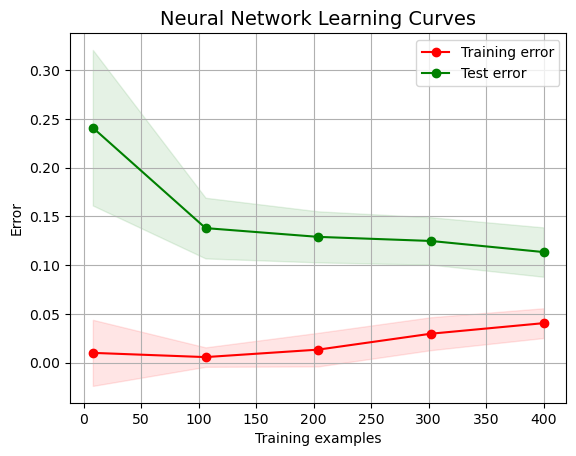

In [8]:
estimator = MLPClassifier(solver='lbfgs', alpha=1e-5,hidden_layer_sizes=(200, 4), random_state=1)
plot_learning_curve(estimator, "Neural Network Learning Curves", X, y, cv=cv, n_jobs=4, train_sizes = np.linspace(0.01, .5, 5))

## Describe and Explain
Describe the results of the two learning curves and explain the differences in terms of what you currently understand about the relationship between $E_{in}$ and $E_{out}$ and the number of training samples, N. Provide clear explanations:

- Why the training error is (generally) lower than the test error.
- Why it is possible for the training error to be higher than the test error.
- Why the training error increases as the number of training samples is increased.
- Which of the two models is the more complex model.

### Answer


#### Why the training error is (generally) lower than the test error?
The training error is calculated on the data the model has seen during training, and it measures how well the model fits the training data. The model has learned the patterns in this data, so it tends to perform well on it. However, the test error is calculated on unseen data, representing the model's generalisation ability. If the model overfits the training data, it may not generalise well to new, unseen data, leading to a higher test error.

#### Why is it possible for the training error to be higher than the test error?
While uncommon, it is possible for the training error to be higher than the test error in situations where the model overfits noise or outliers in the training data. Overfitting occurs when a model captures noise or peculiarities in the training data that do not generalise well. In such cases, the model may perform poorly on the training data but better on the test data, which lacks the noise.

#### Why the training error increases as the number of training samples is increased?
This is unusual and might indicate an issue in the learning process. In a well-behaved learning scenario, as you increase the number of training samples, the model should have more information to learn from, potentially improving its performance on the training data. Increasing training error with more data might indicate issues such as model instability or convergence problems.

#### Which of the two models is the more complex model?
Generally, neural networks are considered more complex models than logistic regression. Neural networks can capture intricate patterns and relationships in data because they can learn hierarchical representations. They consist of multiple layers and parameters, allowing them to model complex functions. Logistic regression, on the other hand, is a linear model with a single layer, making it less complex compared to neural networks.

# Task 3

## Provided functions

Below functions implement linear regression in a closed form (one-step solution using the pseudo-inverse).

In [9]:
def linreg_weights(X,y):
    '''Returns the weight vector associated with the regression line that best describes the data X,y in an MSE fashion '''
    # add bias 1 to inputs X
    X = np.concatenate((np.ones((X.shape[0],1)),X.reshape(X.shape[0],X.shape[1])),axis=1)
    # Calculation of weights using pseudo-inverse.
    return np.linalg.inv((X.T.dot(X))).dot(X.T).dot(y)

In [10]:
def linreg_predict(w,X):
    ''' Returns a prediction y for data point X for a linear regression described by weights w '''
    # add bias 1 to inputs X
    X = np.concatenate((np.ones((X.shape[0],1)),X.reshape(X.shape[0],X.shape[1])),axis=1)
    
    # Calculation of outputs given weights and data (X). 
    out=[]
    for x in X:
        out.append(w.T.dot(x))
    return np.array(out)

# Task 3a

### Answer

In [11]:
def calc_error(w,X,y):
    # implement your error function for linear regression here

SyntaxError: incomplete input (3028167796.py, line 2)

You may add as many cells below as you require.

##  Describe and Explain
Discuss your results and answer the following questions:
1. Which data point adds the biggest error term to the optimised error function?
2. How does the error contributed by this point relate to its distance from the regression line/function? 
3. How do outliers effect linear regression and why?
4. Under what circumstances will linear regression with a squared error measure be a good model?

Provide your answer in this cell..

# Task 3b

For regression the Mean Squared Error measure is a useful error measure. In this task we will explore how useful mean squared error is for classification. To this end:

- Use the provided code to classify the provided data using the linear classification algorithm
- Note that linear classification is implemented by putting the output of the linear regression model through the sign function

### Question

- #### Perform a classification using the provided data in Et1_Task3b.csv.
    - Add a function implementing the error function used in linear classification.
    - Use the provided linear regression code to implement linear classification as described in video 3 (book Learning from Data, page 89).
    - Plot the output of your classification as a scatter plot with the colour of the data point indicating its class membership.
    - Plot the decision boundary in the same plot using the provided function.
    - Quantify the error with the error function you have created.

- #### In new (but similar) plots, add one data point to the dataset to illustrate how linear classification responds to outliers.

- #### Add one more plot of the data with decision boundaries for both linear classification and logistic regression.

- #### Discuss your results and answer the following:
    1. Provide an indication of the contribution of the outlier to the overall MSE error.
    2. Provide an indication of the contribution of the outlier to the error measure used by logistic regression. 
    3. Is linear classification with mean squared error a suitable classifier? Please provide reasons.

### Answer

In [12]:
# fetch the dataset(csv file) into data and define X(column 0,1) and y(column 2)
data = np.loadtxt("Et1_Task3b.csv", delimiter=",")
X = data[:,0:2]  # slice the data by column 0 and 1)
y = data[:,2]    # slice the data by column 2 only)

# calculate weight using pseudo-inverse from X and y
w = linreg_weights(X,y)

In [13]:
# print dataset in table format
print(f'\nDataset {np.shape(data)}:')
dataset = np.hstack((np.vstack(X), np.vstack(y)))
headers = ['#', 'X1', 'X2', 'y']
print(tabulate(dataset, headers, tablefmt="pretty", showindex=True))


Dataset (100, 3):
+----+-----------------------+----------------------+------+
| #  |          X1           |          X2          |  y   |
+----+-----------------------+----------------------+------+
| 0  |  1.7434965718042295   |  -2.140395655406194  | 1.0  |
| 1  |  -1.4079705391189712  |  1.3746769395743839  | -1.0 |
| 2  |  -1.0778217613698378  |  0.9120739318815551  | -1.0 |
| 3  |  -1.7586823434258023  |  0.470778485535169   | -1.0 |
| 4  |  -0.7706824356296403  | -0.7762706591357826  | 1.0  |
| 5  |  0.17394568577545164  |  1.5429294148172037  | -1.0 |
| 6  |  1.5696786074945697   | -1.4124268610149053  | 1.0  |
| 7  |  1.5029269929654006   | -0.3747196743995002  | 1.0  |
| 8  | -0.40703868207846633  | 0.03002034107015644  | 1.0  |
| 9  |  -0.6178017514152833  |  1.4474862215382247  | -1.0 |
| 10 |  -0.4666429613052812  |  0.8966539881166179  | -1.0 |
| 11 | -0.35567245682930065  | -0.7860576545065572  | 1.0  |
| 12 |  -1.565088951276439   |  0.5957795245250687  | -1.0 |
| 13 

In [14]:
# implement error function for linear classification
def calc_class_error(w, X, y):
    """
    Calculate the classification error for linear classification.

    Parameters:
    - w: Weight vector
    - X: Input features
    - y: True labels

    Returns:
    - error_rate: Classification error rate
    """

    # add bias 1 to inputs X
    X_bias = np.concatenate((np.ones((X.shape[0],1)),X.reshape(X.shape[0],X.shape[1])),axis=1)
    
    # Calculate raw scores (predictions) using the weight vector
    raw_scores = X_bias.dot(w)

    # Predict the class labels based on the sign of raw scores
    predictions = np.sign(raw_scores)

    # Calculate the classification error rate
    error_rate = np.mean(predictions != y)

    return error_rate

In [15]:
# implement linear classification algorithm 
def linclass_predict(w,X):
    """
    Predict class labels for input features X using linear classification.

    Parameters:
    - w: Weight vector obtained from linear regression (including bias)
    - X: Input features

    Returns:
    - predictions: Predicted class labels (1 or -1)
    """
    
    # add bias 1 to inputs X
    #X_bias = np.concatenate((np.ones((X.shape[0], 1)), X), axis=1)
    X_bias = np.concatenate((np.ones((X.shape[0],1)),X.reshape(X.shape[0],X.shape[1])),axis=1)
    
    # Calculation of outputs given weights and data (X)
    predictions = np.sign(X_bias.dot(w))

    return predictions

In [16]:
# Use the linear classification predict function
predictions = linclass_predict(w, X)

# Print the predictions
print(f'Predictions: {predictions}')

Predictions: [ 1. -1. -1. -1.  1. -1.  1.  1. -1. -1. -1.  1. -1.  1. -1. -1.  1.  1.
 -1. -1.  1. -1.  1.  1.  1.  1.  1.  1. -1.  1. -1. -1.  1. -1. -1. -1.
 -1.  1. -1.  1. -1.  1. -1. -1. -1.  1. -1.  1. -1. -1.  1.  1. -1.  1.
  1. -1. -1.  1. -1.  1.  1.  1. -1. -1.  1.  1.  1. -1. -1. -1.  1. -1.
 -1. -1. -1. -1.  1. -1.  1. -1. -1.  1.  1.  1.  1.  1.  1.  1. -1. -1.
  1.  1. -1.  1.  1.  1. -1.  1.  1. -1.]


In [19]:
# print prediction in table format
print(f'Prediction data: {len(predictions)} rows')
dataset = np.hstack((np.vstack(X), np.vstack(y), np.vstack(predictions)))
headers = ['#', 'X1', 'X2', 'y', 'predictions']
print(tabulate(dataset, headers, tablefmt="pretty", showindex=True))

Prediction data: 100 rows
+----+-----------------------+----------------------+------+-------------+
| #  |          X1           |          X2          |  y   | predictions |
+----+-----------------------+----------------------+------+-------------+
| 0  |  1.7434965718042295   |  -2.140395655406194  | 1.0  |     1.0     |
| 1  |  -1.4079705391189712  |  1.3746769395743839  | -1.0 |    -1.0     |
| 2  |  -1.0778217613698378  |  0.9120739318815551  | -1.0 |    -1.0     |
| 3  |  -1.7586823434258023  |  0.470778485535169   | -1.0 |    -1.0     |
| 4  |  -0.7706824356296403  | -0.7762706591357826  | 1.0  |     1.0     |
| 5  |  0.17394568577545164  |  1.5429294148172037  | -1.0 |    -1.0     |
| 6  |  1.5696786074945697   | -1.4124268610149053  | 1.0  |     1.0     |
| 7  |  1.5029269929654006   | -0.3747196743995002  | 1.0  |     1.0     |
| 8  | -0.40703868207846633  | 0.03002034107015644  | 1.0  |    -1.0     |
| 9  |  -0.6178017514152833  |  1.4474862215382247  | -1.0 |    -1.0     |

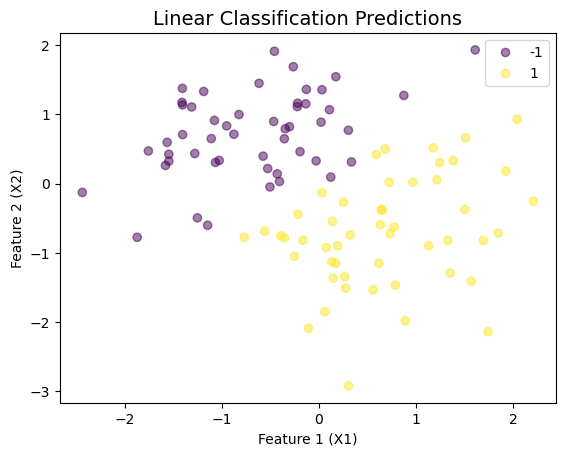

In [21]:
# Plot the output of classification as a scatter plot
scatter = plt.scatter(X[:, 0], X[:, 1], c=predictions, alpha=0.5)
plt.legend(handles=scatter.legend_elements()[0], labels=['-1', '1'])
plt.title('Linear Classification Predictions', fontsize=14)
plt.xlabel('Feature 1 (X1)')
plt.ylabel('Feature 2 (X2)')
plt.show()

In [22]:
def plot_decision_boundary(w, X, y):
    # Plot the data points
    plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.5)

    # Plot the decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
    Z = linclass_predict(w, np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z, colors='r', levels=[0], linewidths=3, alpha=0.5)

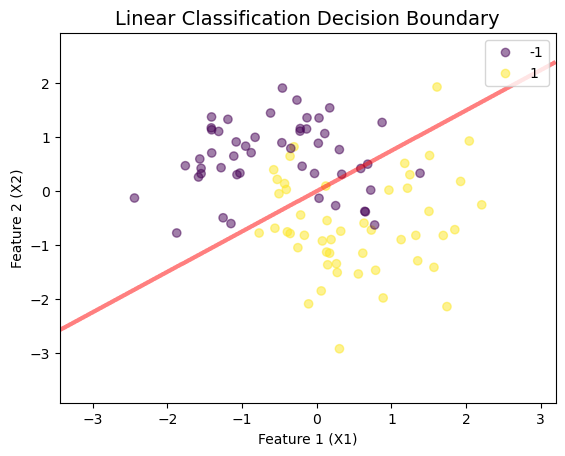

In [23]:
# Plot the decision boundary
plot_decision_boundary(w, X, y)
plt.legend(handles=scatter.legend_elements()[0], labels=['-1', '1'])
plt.title('Linear Classification Decision Boundary', fontsize=14)
plt.xlabel('Feature 1 (X1)')
plt.ylabel('Feature 2 (X2)')
plt.show()

In [24]:
# Quantify the error with the error function
error_rate = calc_class_error(w, X, y)
print(f'Classification Error Rate: {error_rate}')

Classification Error Rate: 0.18


In [222]:
# add one data point to the dataset to illustrate how linear classification responds to outliers.

# Create an outlier
outlier_X = np.array([[3, 3]])
outlier_y = np.array([1])        # assign outlier to class 1

# Add the outlier to the dataset
X_outlier = np.vstack([X, outlier_X])
y_outlier = np.hstack([y, outlier_y])  




[ 1. -1. -1. -1.  1. -1.  1.  1.  1. -1. -1.  1. -1.  1. -1. -1.  1.  1.
  1. -1. -1. -1.  1.  1. -1.  1. -1.  1. -1.  1. -1.  1.  1. -1. -1. -1.
 -1.  1.  1.  1. -1.  1. -1. -1. -1.  1. -1.  1. -1. -1.  1. -1. -1.  1.
  1.  1. -1.  1. -1.  1.  1. -1. -1. -1. -1.  1.  1.  1.  1.  1.  1. -1.
 -1. -1. -1. -1.  1. -1.  1. -1.  1. -1.  1.  1.  1. -1.  1.  1. -1. -1.
  1.  1. -1.  1.  1.  1. -1. -1.  1. -1.  9.]


##  Describe and Explain
Describe the impact of the outlier on both models. Explain why logistic regression is less sensitive to the outlier. 

Provide your answer in this cell..

 # Reflection
 Once you have completed all tasks in this notebook and have studied all other materials for this E-tivity (resources, lectures and live sessions), answer the following questions.
<ol>
<li>Summarise your understanding of how the Hoeffding bound, the concept of 'shattering', break points and the growth function inform the VC bound for a binary classifier. Also discuss how this relates to the general rule of thumb in machine learning that one needs a number of data points at least equal to 10 times the VC bound.</li>
<li>Summarise your understanding of the approximation-generalisation trade-off in terms of complexity, bias and variance of a model, and the resulting under/overfitting given the available data. </li>
    </ol>

## 1
Provide your answer in this cell..

## 2
Provide your answer in this cell..

<hr style="border:2px solid gray">

# Appendix

## Demonstration of effect of outlier on logistic regression decision boundary for comparision with linear classification

Below code demonstrates the effect of an outlier on the decision boundary chosen by logistic regression. You can use this code to compare the effect of outliers in a classification algorithm using mean square error as the error measure with that in a classification algorithm using log likelihood as the error measure. Moreover, below code provides some good hints for plotting the decision boundary in task 3b :-).

Load data:

In [ ]:
data = np.loadtxt("Et1_Task3b.csv", delimiter=",")
X = data[:,0:2]
y=data[:,2]

Fit model:

In [ ]:
estimator = LogisticRegression(solver='lbfgs')
estimator.fit(X,y)
estimator.score(X,y)

Extract weights from model:

In [ ]:
w_lr = estimator.intercept_
w_lr=np.append(w_lr, estimator.coef_)
w_lr

Add outlier:

In [ ]:
X = np.append(X,[[-2,6]], axis=0)
y = np.append(y,[1],axis=0)

Fit model with outlier:

In [ ]:
estimator = LogisticRegression(solver='lbfgs')
estimator.fit(X,y)
estimator.score(X,y)

Extract new weight vector from model:

In [ ]:
w_lr_2 = estimator.intercept_
w_lr_2=np.append(w_lr_2, estimator.coef_)
w_lr_2

Plot original and new decision boundary using weight vectors. Decision boundary is defined by equation: $w_0+x_0\cdot w_1+x_1 \cdot w_2=0 \rightarrow x_2 = -\frac{w_0}{w_2}-x_1\frac{w_1}{w_2}$

In [32]:
y_p = estimator.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.plot([-2,2],[-w_lr[0]/w_lr[2]+w_lr[1]/w_lr[2]*2,-w_lr[0]/w_lr[2]-w_lr[1]/w_lr[2]*2],'b',label="original data")
plt.plot([-2,2],[-w_lr_2[0]/w_lr_2[2]+w_lr_2[1]/w_lr_2[2]*2,-w_lr_2[0]/w_lr_2[2]-w_lr_2[1]/w_lr_2[2]*2],'r',label='data with outlier')

plt.title("Data with outlier classified with logistic regression")
plt.legend(loc="upper right")
plt.show()
1-sum(abs(y_p-y))/len(y)

NotFittedError: This MLPClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.